# Finite-element equilibrium initialized from polarimetric structure

The previous notebooks treated image pixels as independently loaded material points. This notebook introduces a displacement field shared by neighboring points and solves a two-dimensional finite-element equilibrium problem.

The workflow is

\[
\alpha(X,Y),R(X,Y)
\longrightarrow
\mathbf a_0^e,\beta^e
\longrightarrow
\underset{\mathbf u}{\operatorname{argmin}}\;\Pi[\mathbf u]
\longrightarrow
\mathbf F^e,\boldsymbol\sigma^e.
\]

Here, \(e\) denotes a finite element. The structural fields are reconstructed from synthetic polarimetric maps and transferred to element centroids with a nematic-safe interpolation.

## Objectives

1. reconstruct model-ready structural fields from polarimetric maps;
2. transfer \(\mathbf a_0\) and \(\beta\) to a Q4 finite-element mesh;
3. solve finite-strain mechanical equilibrium under displacement control;
4. verify Jacobian positivity, force balance, stress symmetry, and free-DOF residuals;
5. compare the heterogeneous image-informed model with a uniform structural control;
6. export reproducible element and nodal results.

## 1. Reproducible environment

The notebook locates the repository root automatically and imports the local package from `src/` when it has not been installed in editable mode.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (
    FiniteElementConfig,
    MaterialParameters,
    RetardanceCalibration,
    assemble_internal_energy_and_force,
    element_centroids,
    polarimetry_to_structure,
    rectangular_quad_mesh,
    sample_nematic_image_to_elements,
    solve_displacement_controlled_equilibrium,
    vector_to_angle,
)

np.set_printoptions(precision=6, suppress=True)
print(f"Repository root: {REPOSITORY_ROOT}")
print(f"NumPy version: {np.__version__}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
NumPy version: 1.24.3


## 2. Governing boundary-value problem

In the reference domain \(\Omega_0\), mechanical equilibrium is

\[
\operatorname{Div}_{\!X}\mathbf P=\mathbf 0,
\qquad
\mathbf P=\frac{\partial\psi}{\partial\mathbf F},
\qquad
\mathbf F=\mathbf I+\nabla_X\mathbf u.
\]

The weak form is

\[
\int_{\Omega_0}\mathbf P:\nabla_X\delta\mathbf u\,dV=0
\]

for every admissible virtual displacement \(\delta\mathbf u\). The code minimizes the internal strain energy under prescribed displacement constraints. Four-node bilinear quadrilaterals and \(2\times2\) Gauss integration are used.

Boundary conditions:

- left edge: \(u_x=0\);
- right edge: \(u_x=\Delta\);
- lower-left node: \(u_y=0\), removing rigid vertical translation;
- all remaining vertical degrees of freedom: traction-free.

The lateral contraction and the non-affine displacement field are therefore determined by equilibrium rather than prescribed.

## 3. Reconstruct structural fields from polarimetry

In [2]:
measurement_path = REPOSITORY_ROOT / "data" / "synthetic" / "polarimetry_maps.npz"
measurement = np.load(measurement_path)

calibration = RetardanceCalibration(
    lower_retardance=0.04,
    upper_retardance=0.90,
    beta_min=0.05,
    beta_max=0.95,
    exponent=1.30,
)

structure = polarimetry_to_structure(
    measurement["azimuth_rad"],
    measurement["retardance"],
    calibration,
    minimum_valid_retardance=0.08,
    external_valid_mask=measurement["tissue_mask"],
    coherence_window=9,
)

print(f"Image shape: {measurement['x'].shape}")
print(f"Valid pixels: {np.count_nonzero(structure.valid_mask)}")
print(f"Mean reconstructed beta: {np.nanmean(structure.structural_order):.6f}")

Image shape: (81, 121)
Valid pixels: 6836
Mean reconstructed beta: 0.703541


## 4. Finite-element mesh and nematic-safe transfer

A central rectangular region of the synthetic tissue image is discretized. Element centroids are mapped back to the image coordinates. Fiber directions are not averaged as ordinary vectors, because \(\mathbf a_0\) and \(-\mathbf a_0\) represent the same fiber family. Instead, interpolation is performed in doubled-angle space:

\[
q=\left\langle e^{2i\alpha}\right\rangle,
\qquad
\alpha_e=\frac12\arg q.
\]

In [3]:
mesh = rectangular_quad_mesh(
    number_of_elements_x=6,
    number_of_elements_y=3,
    width=2.0,
    height=1.2,
)
centroids = element_centroids(mesh)

# The FE rectangle [0, 2] x [0, 1.2] corresponds to the central image
# rectangle [-1, 1] x [-0.6, 0.6].
image_centroids = np.column_stack((centroids[:, 0] - 1.0, centroids[:, 1] - 0.6))

element_fiber, element_beta = sample_nematic_image_to_elements(
    image_centroids,
    measurement["x"],
    measurement["y"],
    structure.fiber_direction,
    structure.structural_order,
    structure.valid_mask,
    neighbors=12,
)

element_angle_deg = np.rad2deg(vector_to_angle(element_fiber))

print(f"Nodes: {mesh.number_of_nodes}")
print(f"Elements: {mesh.number_of_elements}")
print(f"Element beta range: {element_beta.min():.6f} -- {element_beta.max():.6f}")
print(f"Element angle range: {element_angle_deg.min():.3f} -- {element_angle_deg.max():.3f} deg")

Nodes: 28
Elements: 18
Element beta range: 0.419786 -- 0.783949
Element angle range: 15.308 -- 69.897 deg


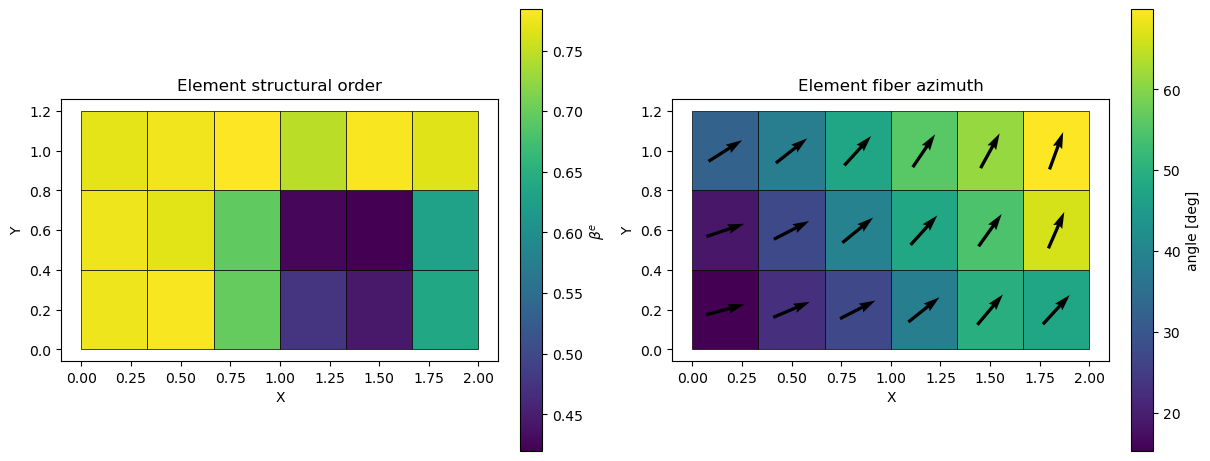

In [4]:
def plot_element_field(
    axis,
    nodes,
    elements,
    values,
    *,
    title,
    label,
    deformed_nodes=None,
):
    coordinates = nodes if deformed_nodes is None else deformed_nodes
    polygons = [coordinates[connectivity] for connectivity in elements]
    collection = PolyCollection(polygons, array=np.asarray(values), edgecolors="black", linewidths=0.5)
    axis.add_collection(collection)
    axis.autoscale_view()
    axis.set_aspect("equal")
    axis.set_title(title)
    axis.set_xlabel("X")
    axis.set_ylabel("Y")
    colorbar = plt.colorbar(collection, ax=axis)
    colorbar.set_label(label)
    return collection


figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
plot_element_field(
    axes[0], mesh.nodes, mesh.elements, element_beta,
    title="Element structural order", label=r"$\beta^e$"
)
plot_element_field(
    axes[1], mesh.nodes, mesh.elements, element_angle_deg,
    title="Element fiber azimuth", label="angle [deg]"
)
axes[1].quiver(
    centroids[:, 0], centroids[:, 1],
    element_fiber[:, 0], element_fiber[:, 1],
    angles="xy", scale_units="xy", scale=5.0, pivot="middle"
)
plt.show()

## 5. Solve the nonlinear equilibrium problem

In [5]:
material = MaterialParameters(
    mu=5.0,
    kappa=100.0,
    k1=2.0,
    k2=3.0,
)

fe_config = FiniteElementConfig(
    axial_extension=0.06,
    load_steps=3,
    gradient_tolerance=1.0e-6,
    maximum_iterations=400,
    minimum_jacobian=0.30,
)

heterogeneous_result = solve_displacement_controlled_equilibrium(
    mesh,
    element_fiber,
    element_beta,
    material,
    fe_config,
)

print(f"Converged load steps: {heterogeneous_result.converged}")
print(f"BFGS iterations: {heterogeneous_result.iterations}")
print(f"Free-DOF residual norm: {heterogeneous_result.free_dof_residual_norm:.3e}")
print(f"Minimum element J: {heterogeneous_result.element_jacobian.min():.6f}")
print(f"Maximum element J: {heterogeneous_result.element_jacobian.max():.6f}")
print(f"Right-edge reaction: {heterogeneous_result.right_reaction}")

Converged load steps: [ True  True  True]
BFGS iterations: [54 52 53]
Free-DOF residual norm: 3.872e-07
Minimum element J: 1.003856
Maximum element J: 1.005540
Right-edge reaction: [ 1.343274 -0.      ]


### 5.1 Deformed mesh and displacement field

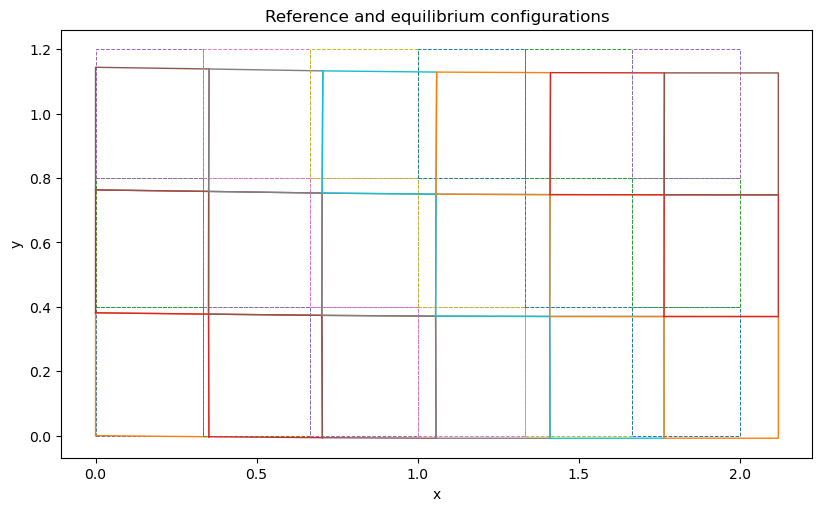

In [6]:
figure, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
for connectivity in mesh.elements:
    reference_polygon = np.vstack((mesh.nodes[connectivity], mesh.nodes[connectivity[0]]))
    deformed_polygon = np.vstack((
        heterogeneous_result.deformed_nodes[connectivity],
        heterogeneous_result.deformed_nodes[connectivity[0]],
    ))
    axis.plot(reference_polygon[:, 0], reference_polygon[:, 1], linestyle="--", linewidth=0.7)
    axis.plot(deformed_polygon[:, 0], deformed_polygon[:, 1], linewidth=1.0)
axis.set_aspect("equal")
axis.set_xlabel("x")
axis.set_ylabel("y")
axis.set_title("Reference and equilibrium configurations")
plt.show()

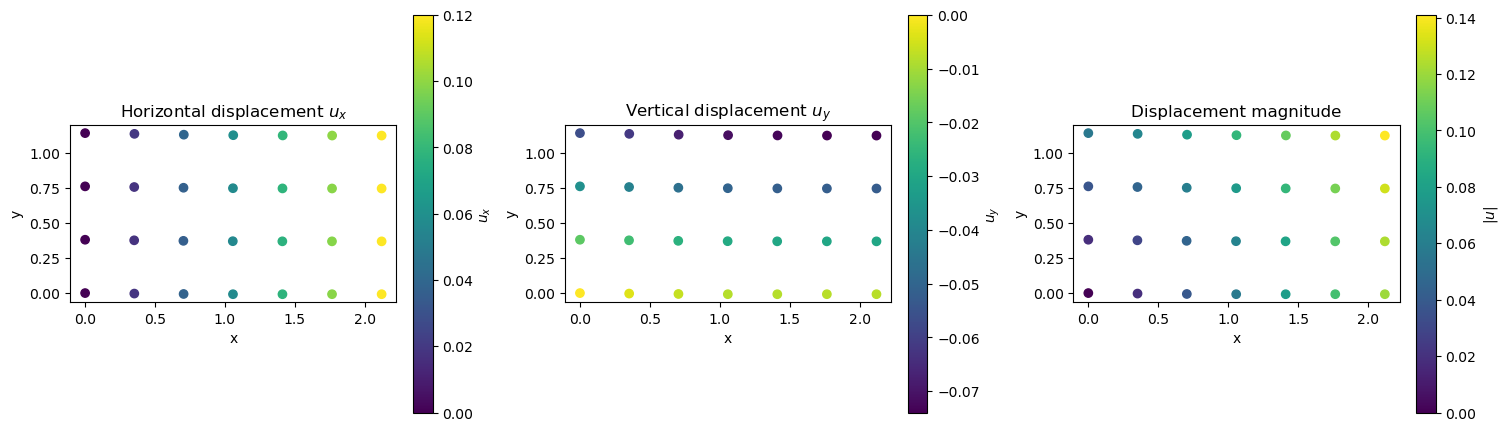

In [7]:
displacement_magnitude = np.linalg.norm(heterogeneous_result.displacement, axis=1)

figure, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for axis, values, title, label in (
    (axes[0], heterogeneous_result.displacement[:, 0], r"Horizontal displacement $u_x$", r"$u_x$"),
    (axes[1], heterogeneous_result.displacement[:, 1], r"Vertical displacement $u_y$", r"$u_y$"),
    (axes[2], displacement_magnitude, r"Displacement magnitude", r"$|u|$"),
):
    scatter = axis.scatter(
        heterogeneous_result.deformed_nodes[:, 0],
        heterogeneous_result.deformed_nodes[:, 1],
        c=values,
    )
    axis.set_aspect("equal")
    axis.set_title(title)
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    plt.colorbar(scatter, ax=axis, label=label)
plt.show()

### 5.2 Element mechanical fields

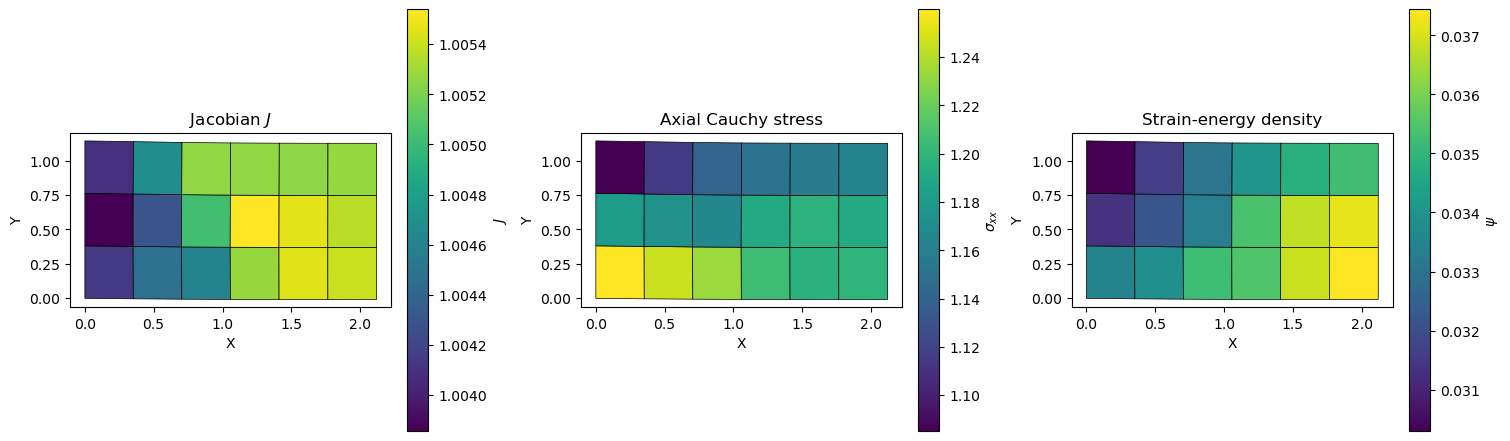

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(15, 4.3), constrained_layout=True)
plot_element_field(
    axes[0], mesh.nodes, mesh.elements, heterogeneous_result.element_jacobian,
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title=r"Jacobian $J$", label=r"$J$"
)
plot_element_field(
    axes[1], mesh.nodes, mesh.elements, heterogeneous_result.element_cauchy_stress[:, 0, 0],
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title=r"Axial Cauchy stress", label=r"$\sigma_{xx}$"
)
plot_element_field(
    axes[2], mesh.nodes, mesh.elements, heterogeneous_result.element_strain_energy,
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title="Strain-energy density", label=r"$\psi$"
)
plt.show()

## 6. Equilibrium and consistency checks

The computed state should satisfy:

1. \(J>0\) in every element;
2. negligible residual force on unconstrained degrees of freedom;
3. balance of total left and right reactions;
4. symmetric Cauchy stress;
5. lower energy than a kinematically admissible but generally non-equilibrium affine comparison field.

In [9]:
# Area-preserving affine comparison with the same prescribed axial displacement.
lambda_x = 1.0 + fe_config.axial_extension
affine_f = np.diag([lambda_x, 1.0 / lambda_x])
affine_displacement = mesh.nodes @ (affine_f - np.eye(2)).T

affine_energy, affine_force, *_ = assemble_internal_energy_and_force(
    mesh,
    affine_displacement,
    element_fiber,
    element_beta,
    material,
)
equilibrium_energy, _, *_ = assemble_internal_energy_and_force(
    mesh,
    heterogeneous_result.displacement,
    element_fiber,
    element_beta,
    material,
)

reaction_imbalance = heterogeneous_result.left_reaction + heterogeneous_result.right_reaction
stress_asymmetry = np.max(
    np.abs(
        heterogeneous_result.element_cauchy_stress
        - np.swapaxes(heterogeneous_result.element_cauchy_stress, -1, -2)
    )
)
energy_reduction = (affine_energy - equilibrium_energy) / affine_energy

checks = {
    "all load steps converged": bool(np.all(heterogeneous_result.converged)),
    "positive current Jacobian": bool(np.all(heterogeneous_result.element_jacobian > 0.0)),
    "small free-DOF residual": bool(heterogeneous_result.free_dof_residual_norm < 1.0e-5),
    "balanced horizontal reactions": bool(abs(reaction_imbalance[0]) < 1.0e-5),
    "symmetric Cauchy stress": bool(stress_asymmetry < 1.0e-12),
    "equilibrium energy below affine comparison": bool(equilibrium_energy < affine_energy),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")

print(f"\nReaction imbalance: {reaction_imbalance}")
print(f"Maximum stress asymmetry: {stress_asymmetry:.3e}")
print(f"Equilibrium energy: {equilibrium_energy:.9f}")
print(f"Affine comparison energy: {affine_energy:.9f}")
print(f"Relative energy reduction: {100.0 * energy_reduction:.3f}%")

assert all(checks.values())

PASS — all load steps converged
PASS — positive current Jacobian
PASS — small free-DOF residual
PASS — balanced horizontal reactions
PASS — symmetric Cauchy stress
PASS — equilibrium energy below affine comparison

Reaction imbalance: [-0. -0.]
Maximum stress asymmetry: 1.041e-17
Equilibrium energy: 0.082339711
Affine comparison energy: 0.086360448
Relative energy reduction: 4.656%


## 7. Uniform-structure control

To isolate the effect of the spatial microstructure, a second model is solved with the same mesh, material parameters, and boundary conditions, but with constant \(\beta\) and a single mean nematic orientation.

In [10]:
element_angles = vector_to_angle(element_fiber)
mean_cosine = np.mean(np.cos(2.0 * element_angles))
mean_sine = np.mean(np.sin(2.0 * element_angles))
mean_angle = 0.5 * np.arctan2(mean_sine, mean_cosine)
mean_fiber = np.array([np.cos(mean_angle), np.sin(mean_angle)])

uniform_fiber = np.tile(mean_fiber, (mesh.number_of_elements, 1))
uniform_beta = np.full(mesh.number_of_elements, np.mean(element_beta))

uniform_result = solve_displacement_controlled_equilibrium(
    mesh,
    uniform_fiber,
    uniform_beta,
    material,
    fe_config,
)

heterogeneous_reaction = float(heterogeneous_result.right_reaction[0])
uniform_reaction = float(uniform_result.right_reaction[0])
heterogeneous_stress_std = float(np.std(heterogeneous_result.element_cauchy_stress[:, 0, 0]))
uniform_stress_std = float(np.std(uniform_result.element_cauchy_stress[:, 0, 0]))

print(f"Mean nematic angle: {np.rad2deg(np.mod(mean_angle, np.pi)):.6f} deg")
print(f"Mean beta: {np.mean(element_beta):.6f}")
print(f"Heterogeneous reaction: {heterogeneous_reaction:.6f}")
print(f"Uniform reaction:       {uniform_reaction:.6f}")
print(f"Reaction difference:    {heterogeneous_reaction - uniform_reaction:.6f}")
print(f"Heterogeneous sigma_xx standard deviation: {heterogeneous_stress_std:.6f}")
print(f"Uniform sigma_xx standard deviation:       {uniform_stress_std:.6f}")

Mean nematic angle: 42.239664 deg
Mean beta: 0.674621
Heterogeneous reaction: 1.343274
Uniform reaction:       1.284361
Reaction difference:    0.058913
Heterogeneous sigma_xx standard deviation: 0.042194
Uniform sigma_xx standard deviation:       0.005095


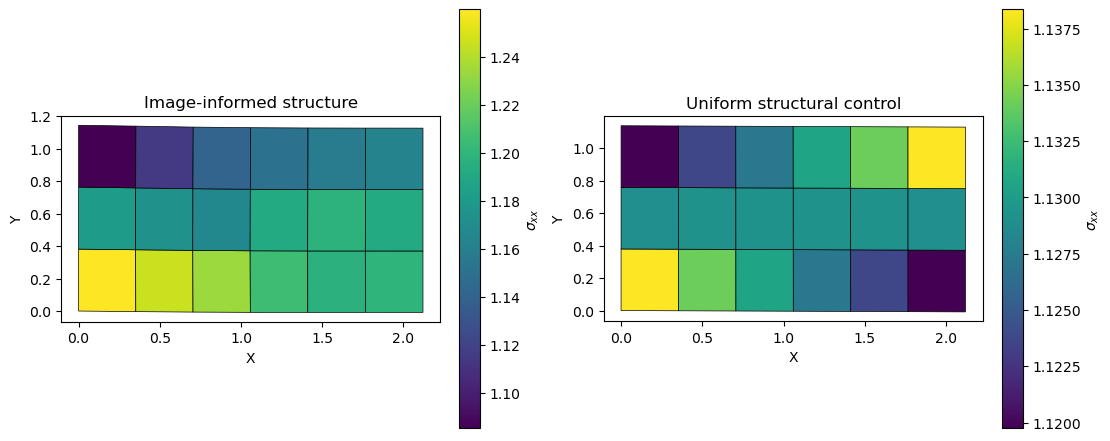

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
plot_element_field(
    axes[0], mesh.nodes, mesh.elements,
    heterogeneous_result.element_cauchy_stress[:, 0, 0],
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title="Image-informed structure", label=r"$\sigma_{xx}$"
)
plot_element_field(
    axes[1], mesh.nodes, mesh.elements,
    uniform_result.element_cauchy_stress[:, 0, 0],
    deformed_nodes=uniform_result.deformed_nodes,
    title="Uniform structural control", label=r"$\sigma_{xx}$"
)
plt.show()

## 8. Export reproducible results

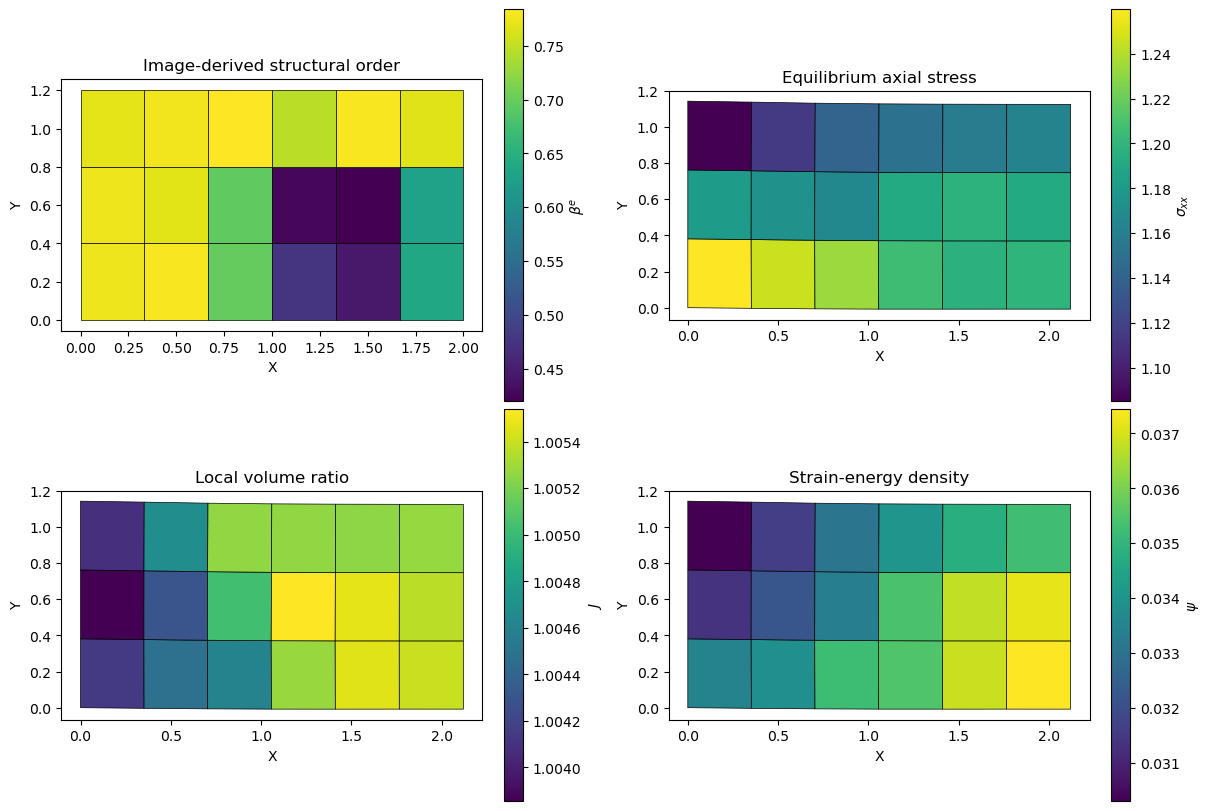

Saved: results\data\finite_element_equilibrium_fields.npz
Saved: results\data\finite_element_equilibrium_metrics.csv
Saved: results\figures\finite_element_equilibrium_summary.png


In [12]:
output_data_directory = REPOSITORY_ROOT / "results" / "data"
output_figure_directory = REPOSITORY_ROOT / "results" / "figures"
output_data_directory.mkdir(parents=True, exist_ok=True)
output_figure_directory.mkdir(parents=True, exist_ok=True)

npz_path = output_data_directory / "finite_element_equilibrium_fields.npz"
np.savez_compressed(
    npz_path,
    nodes=mesh.nodes,
    elements=mesh.elements,
    displacement=heterogeneous_result.displacement,
    deformed_nodes=heterogeneous_result.deformed_nodes,
    element_centroids=centroids,
    element_fiber_direction=element_fiber,
    element_structural_order=element_beta,
    element_deformation_gradient=heterogeneous_result.element_deformation_gradient,
    element_jacobian=heterogeneous_result.element_jacobian,
    element_strain_energy=heterogeneous_result.element_strain_energy,
    element_cauchy_stress=heterogeneous_result.element_cauchy_stress,
    nodal_internal_force=heterogeneous_result.nodal_internal_force,
)

csv_path = output_data_directory / "finite_element_equilibrium_metrics.csv"
metric_names = np.array([
    "free_dof_residual_norm",
    "minimum_jacobian",
    "maximum_jacobian",
    "right_reaction_x",
    "reaction_imbalance_x",
    "equilibrium_energy",
    "affine_energy",
    "relative_energy_reduction",
    "heterogeneous_sigma_xx_std",
    "uniform_right_reaction_x",
    "uniform_sigma_xx_std",
])
metric_values = np.array([
    heterogeneous_result.free_dof_residual_norm,
    np.min(heterogeneous_result.element_jacobian),
    np.max(heterogeneous_result.element_jacobian),
    heterogeneous_reaction,
    reaction_imbalance[0],
    equilibrium_energy,
    affine_energy,
    energy_reduction,
    heterogeneous_stress_std,
    uniform_reaction,
    uniform_stress_std,
])
np.savetxt(
    csv_path,
    np.column_stack((metric_names, metric_values.astype(str))),
    fmt="%s",
    delimiter=",",
    header="metric,value",
    comments="",
)

figure, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
plot_element_field(
    axes[0, 0], mesh.nodes, mesh.elements, element_beta,
    title="Image-derived structural order", label=r"$\beta^e$"
)
plot_element_field(
    axes[0, 1], mesh.nodes, mesh.elements,
    heterogeneous_result.element_cauchy_stress[:, 0, 0],
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title="Equilibrium axial stress", label=r"$\sigma_{xx}$"
)
plot_element_field(
    axes[1, 0], mesh.nodes, mesh.elements,
    heterogeneous_result.element_jacobian,
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title="Local volume ratio", label=r"$J$"
)
plot_element_field(
    axes[1, 1], mesh.nodes, mesh.elements,
    heterogeneous_result.element_strain_energy,
    deformed_nodes=heterogeneous_result.deformed_nodes,
    title="Strain-energy density", label=r"$\psi$"
)
summary_path = output_figure_directory / "finite_element_equilibrium_summary.png"
figure.savefig(summary_path, dpi=180)
plt.show()

print(f"Saved: {npz_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {csv_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {summary_path.relative_to(REPOSITORY_ROOT)}")

## 9. Interpretation

This notebook changes the mechanical meaning of the model. Neighboring material points are no longer allowed to follow independently prescribed deformation gradients. Instead, all elements share a continuous nodal displacement field and must collectively satisfy equilibrium.

The image-derived variation in fiber orientation and structural order produces:

- a non-affine displacement field;
- spatially heterogeneous \(J\), energy, and Cauchy stress;
- a reaction force that differs from the uniform-structure control;
- stress heterogeneity that cannot be reproduced by replacing the image with mean parameters alone.
